# Discrete Multi-Exponential Lifetime Fitting

`LifetimeFitter` fits a positron annihilation lifetime (PALS) spectrum with a **small, fixed
number of exponential components**. It is the right tool when the sample is expected to have a
few well-defined annihilation states -- bulk, one dominant defect type, a source contribution.
When no such parametric assumption is available, the problem becomes an *inversion* instead;
see `lifetime_inversion.ipynb` and `gp_inversion.ipynb`.

## Model

$$
N(t) \;=\; T\,\Delta t \;\Big[\,\mathrm{IRF}(t-t_0) \otimes \sum_i \frac{I_i}{\tau_i}\,
e^{-t/\tau_i}\,\Theta(t)\,\Big] \;+\; \mathrm{bg},
\qquad T \;=\; \sum_k N_k \;-\; \mathrm{bg}\cdot M
$$

with $M$ the number of bins and $\Delta t$ the bin width. 

| quantity | role in the fit |
|---|---|
| $\tau_i$, $t_0$, bg | `FitParameter` -- free, bounded, or fixed; these are what reach the optimizer |
| $I_i$ | **not** parameters -- solved by non-negative least squares at every optimization trial |
| $T$ | pinned to the measured counts, never fitted |

Uncertainties are **not** rescaled by a reduced $\chi^2$. Residuals are divided by the known
Poisson error of each bin, so the covariance already carries an absolute scale; multiplying by
$\chi^2_{red}$ would double-count it.

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scispectrum import Spectrum
from scipas.core.lifetime import PASLifetime
from scipas.core.time_resolution import MultiGaussianRF
from scipas.model.lifetime import LifetimeModel
from scipas.analysis.lifetime import (
    generate_random_lt_spectrum,
    LifetimeFitter,
    FitParameter,
)

## 1. Instrument response and the time grid

The response function (IRF) is the detector's timing resolution: the spectrum a perfectly
prompt annihilation would produce. `MultiGaussianRF` is a normalised sum of Gaussians, and a
single 230 ps FWHM Gaussian is a reasonable stand-in for a fast plastic-scintillator PALS setup.

All times are in **nanoseconds**. The grid must span $t < 0$, so that the onset lies inside the
window and the convolution has somewhere to put the rise.

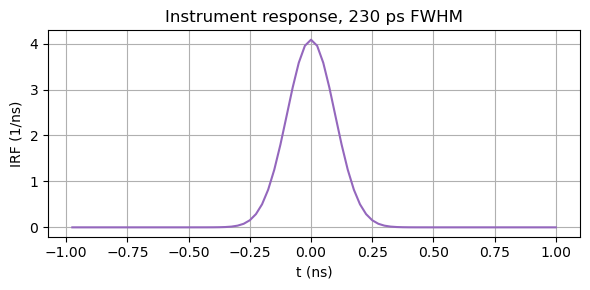

In [46]:
time = np.arange(-2.0, 15.0, 0.025)          # ns; 25 ps channels, 680 bins
fwhm = 0.230                                 # ns; detector timing resolution
irf_sigma = np.array([fwhm / (2 * np.sqrt(2 * np.log(2)))])

irf = MultiGaussianRF(sigmas=irf_sigma,
                      weights=np.ones_like(irf_sigma),
                      t0=np.zeros_like(irf_sigma))

window = np.abs(time) < 1.0
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(time[window], irf.evaluate(time[window]), color="tab:purple")
ax.set_xlabel("t (ns)")
ax.set_ylabel("IRF (1/ns)")
ax.set_title(f"Instrument response, {1000 * fwhm:.0f} ps FWHM")
fig.tight_layout()
plt.grid()

## 2. Synthetic two-component spectrum

Ground truth: $\tau_0 = 0.22$ ns at 75 % and $\tau_1 = 1.80$ ns at 25 %, on a flat background of
20 counts/bin, from $2\times10^{6}$ annihilation events.

The time-zero offset is injected by centring the **generating** IRF at $t_0 = 0.05$ ns, while the
`PASLifetime` handed to the fitter carries a **centred** IRF. The fit must therefore absorb the
shift through its free $t_0$.

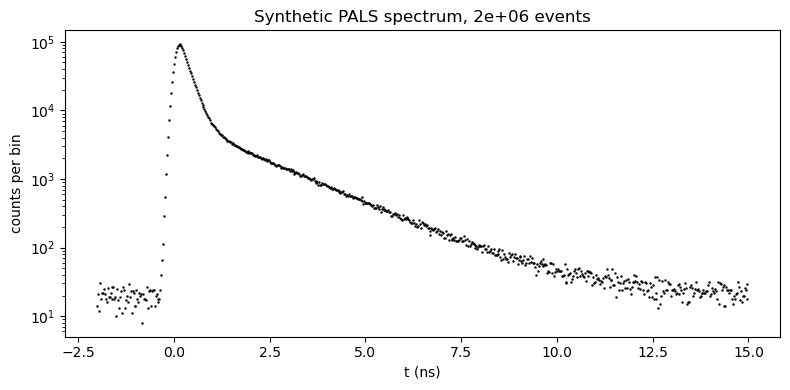

In [47]:
true_taus = np.array([0.22, 1.80])           # ns
true_intensities = np.array([0.75, 0.25])
true_t0 = 0.05                               # ns
true_background = 20.0                       # counts per bin
num_events = 2_000_000

truth = LifetimeModel("truth", lifetimes=true_taus, intensities=true_intensities)

# The offset is injected by centring the *generating* response at true_t0.
generating_irf = MultiGaussianRF(sigmas=irf_sigma,
                                 weights=np.ones_like(irf_sigma),
                                 t0=np.full_like(irf_sigma, true_t0))

decay = generate_random_lt_spectrum(time, truth, generating_irf,
                                    num_events=num_events, rng=7)

# A flat background is itself Poisson. Drawing it, rather than adding a constant,
# keeps the spectrum a genuine Poisson realisation -- so the 1/sqrt(counts) weights
# the fitter uses describe the noise that is actually in the data.
background_counts = np.random.default_rng(11).poisson(true_background, size=len(time))

pals = PASLifetime(
    lifetime=Spectrum(counts=decay.lifetime.counts + background_counts,
                      axis_calib=decay.lifetime.axis_calib),
    resolution=irf,          # centred: the fit has to find t0 for itself
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(time, pals.lifetime.counts, ".", ms=1.5, color="black")
ax.set_xlabel("t (ns)")
ax.set_ylabel("counts per bin")
ax.set_title(f"Synthetic PALS spectrum, {num_events:.0e} events")
fig.tight_layout()

## 3. What is a parameter, and what is not

The model is **linear in the intensities** and nonlinear in everything else. Given
$(\tau_i, t_0, \mathrm{bg})$, the best intensities follow from a single non-negative
least-squares solve against the data - there is nothing to search for. The fitter exploits this
(*variable projection*): only $[\tau_0,\dots,\tau_{n-1}, t_0, \mathrm{bg}]$ reach
`least_squares`, and the intensities are recovered inside every residual evaluation.

Two consequences you will feel immediately:

- **There is no `FitParameter` for an intensity.** You configure lifetimes, $t_0$ and background,
  and nothing else. After optimization, `FitResult.opt_parameters()` re-solves the intensities when you ask for them.
- The optimizer searches $n+2$ dimensions instead of $2n+2$, which is why the fit converges relativly fast.

In [48]:
pre_onset = pals.lifetime.counts[time < -0.5]
background_estimate = pre_onset.mean()
print(f"background from {pre_onset.size} pre-onset bins: "
      f"{background_estimate:.2f} counts/bin   (true value {true_background})")

lifetime_components = [
    FitParameter(value=0.10, lower=0.01, upper=0.80),    # short component
    FitParameter(value=1.20, lower=0.80, upper=10.0),    # long component
]
t0 = FitParameter(value=0.0, lower=-1.0, upper=1.0)
background = FitParameter(value=background_estimate, lower=0.0, upper=100.0, fixed=True)

background from 61 pre-onset bins: 19.56 counts/bin   (true value 20.0)


### Fixing the background

The bins before the onset contain background only, so the background can be **measured** instead
of fitted -- which is what the cell above does, and why it is passed as `fixed=True`.

Fitting it is perfectly legitimate too, but worth knowing what it costs. The residuals are Neyman
weighted (meaning each residual is divided by $\sqrt{\text{observed counts}}$), which is what keeps the fit separable between non-linear and linear parameters, and
that weighting biases a level parameter low by about **one count per bin**. The bias is an
absolute offset, not a relative one, and it lands on the background -- a nuisance parameter --
while $\tau$ and $t_0$ barely move. Fixing a separately measured value removes even that.

A fixed parameter keeps the value it was given and receives a zero row and column in the
covariance, which section 4 shows directly.

## 4. Run the fit and read the result

`fit` returns a `FitResult`. Its `popt`, `pcov` and `free` are `xr.DataArray`s over a single
`parameter` coordinate, `[tau_0, ..., tau_{n-1}, t0, background]`. Both arrays are **full
slot-sized**: a fixed parameter still occupies its slot, holding the value it was fixed to.

In [49]:
fitter = LifetimeFitter()
result = fitter.fit(pals=pals,
                    lifetime_components=lifetime_components,
                    t0=t0,
                    background=background)
result.optimizer

OptimizerOutput(success=True, status=2, message='`ftol` termination condition is satisfied.', nfev=7)

In [50]:
result.popt

<xarray.DataArray (parameter: 4)> Size: 32B
array([ 0.21966092,  1.79017518,  0.05012421, 19.55737705])
Coordinates:
  * parameter  (parameter) <U10 160B 'tau_0' 'tau_1' 't0' 'background'

In [51]:
result.pcov

<xarray.DataArray (parameter: 4, parameter0: 4)> Size: 128B
array([[ 1.61190763e-07,  7.34476407e-07, -4.42779191e-08,
         0.00000000e+00],
       [ 7.34476407e-07,  1.65856459e-05, -1.23552371e-07,
         0.00000000e+00],
       [-4.42779191e-08, -1.23552371e-07,  3.24763818e-08,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00]])
Coordinates:
  * parameter   (parameter) <U10 160B 'tau_0' 'tau_1' 't0' 'background'
  * parameter0  (parameter0) <U10 160B 'tau_0' 'tau_1' 't0' 'background'

The `background` row and column of `pcov` are exactly zero - the fixed parameter carrying no
uncertainty. That is not cosmetic: it means anything propagating `pcov` (an error band, a
derived quantity, the sampler in section 6) gets the right answer with **no special case for
fixed parameters**, because a zero-variance direction simply reproduces the fixed value in every
draw.

In [52]:
fit_tau, fit_intensities, fit_t0, fit_background = result.opt_parameters()
sigma = np.sqrt(np.diag(result.pcov.values))

pd.DataFrame(
    {
        "truth": [*true_taus, *true_intensities, true_t0, true_background],
        "fit": [*fit_tau, *fit_intensities, fit_t0, fit_background],
        "sigma": [sigma[0], sigma[1], np.nan, np.nan, sigma[2], sigma[3]],
    },
    index=["tau_0 (ns)", "tau_1 (ns)", "I_0", "I_1", "t0 (ns)", "background"],
)

,truth,fit,sigma
tau_0 (ns),0.22,0.219661,0.000401
tau_1 (ns),1.80,1.790175,0.004073
I_0,0.75,0.749849,NaN
I_1,0.25,0.249948,NaN
t0 (ns),0.05,0.050124,0.000180
background,20.00,19.557377,0.000000


The two intensity rows have no `sigma`. That is the variable projection showing through: the
intensities are not optimizer parameters, so they have no entry in `pcov`. Section 6 obtains
their uncertainty by a route that suits how they are actually produced.

## 5. The model curve

`generate` evaluates the model on the measured grid, using the same
$T\,\Delta t\,\mathrm{decay} + \mathrm{bg}$ expression the optimizer minimised against, so the
result is directly comparable with the data.

It requires **all four** of lifetimes, intensities, $t_0$ and background, and never solves the
intensities itself. That is deliberate: solving them would return the best-fit intensities for
the lifetimes it was handed and silently discard any that were *drawn*, which would collapse the
uncertainty band of section 6 onto its lifetime term alone. Use `opt_parameters()` or `sample()`
to obtain a complete, mutually consistent set.

A good fit shows weighted residuals scattering inside roughly $\pm 3$ with no structure, and
$\chi^2$ per bin near 1.

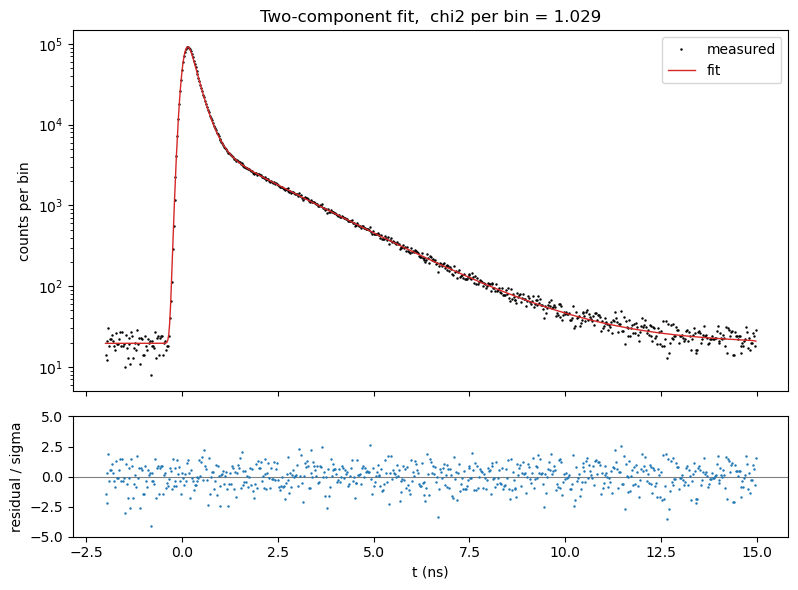

In [53]:
pals_fit = result.generate(lifetimes=fit_tau,
                           intensities=fit_intensities,
                           t0=fit_t0,
                           background=fit_background)

model = pals_fit.lifetime.counts
sigma_counts = np.sqrt(np.maximum(pals.lifetime.counts, 1.0))
weighted_residual = (pals.lifetime.counts - model) / sigma_counts
chi2_per_bin = np.sum(weighted_residual ** 2) / len(time)

fig, (ax_top, ax_bot) = plt.subplots(2, 1, sharex=True, figsize=(8, 6),
                                     gridspec_kw={"height_ratios": [3, 1]})
ax_top.semilogy(time, pals.lifetime.counts, ".", ms=1.5, color="black", label="measured")
ax_top.semilogy(time, model, color="tab:red", lw=1.0, label="fit")
ax_top.set_ylabel("counts per bin")
ax_top.set_title(f"Two-component fit,  chi2 per bin = {chi2_per_bin:.3f}")
ax_top.legend()

ax_bot.axhline(0.0, color="grey", lw=0.8)
ax_bot.plot(time, weighted_residual, ".", ms=1.5, color="tab:blue")
ax_bot.set_ylim(-5, 5)
ax_bot.set_xlabel("t (ns)")
ax_bot.set_ylabel("residual / sigma")
fig.tight_layout()

## 6. Uncertainties by hierarchical sampling

`sample(size)` draws complete parameter sets, intensities included, in **two stages per draw**:

1. the nonlinear parameters from $\mathcal{N}(\texttt{popt}, \texttt{pcov})$;
2. the intensities solved at *those* parameters, then drawn from
   $\mathcal{N}(I, \mathrm{cov}(I|\tau))$.

Together the stages realise

$$\mathrm{cov}(I) \;=\; \mathbb{E}\big[\mathrm{cov}(I|\tau)\big] \;+\;
\mathrm{cov}\big(\mathbb{E}[I|\tau]\big)$$

and, because the two stages stay paired within a draw, the $\tau$-$I$ cross terms as well.

`sample` returns the same four things as `opt_parameters()`, differing only by a leading draw
axis, so any draw can be fed straight back into `generate`.

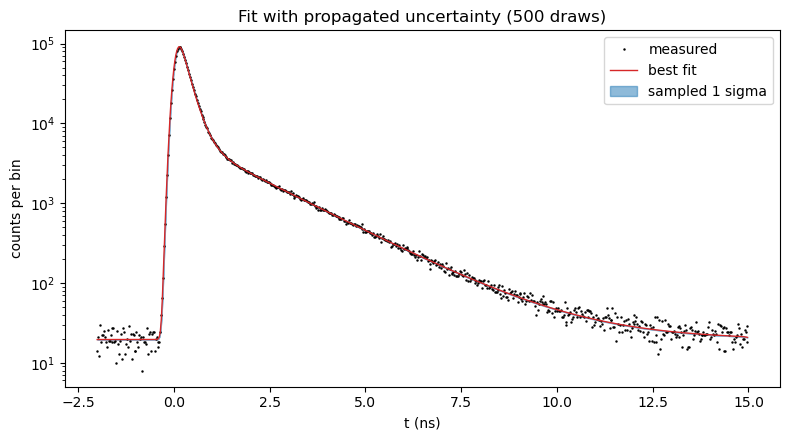

In [54]:
num_draws = 500
sample_tau, sample_intensities, sample_t0, sample_background = result.sample(size=num_draws, rng=1)

sampled_counts = np.empty((num_draws, len(time)))
for k in range(num_draws):
    sampled_counts[k] = result.generate(lifetimes=sample_tau[k],
                                        intensities=sample_intensities[k],
                                        t0=sample_t0[k],
                                        background=sample_background[k]).lifetime.counts

band_mean = sampled_counts.mean(axis=0)
band_std = sampled_counts.std(axis=0)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(time, pals.lifetime.counts, ".", ms=1.5, color="black", label="measured")
ax.semilogy(time, model, color="tab:red", lw=1.0, label="best fit")
ax.fill_between(time, band_mean - band_std, band_mean + band_std,
                color="tab:blue", alpha=0.5, label="sampled 1 sigma")
ax.set_xlabel("t (ns)")
ax.set_ylabel("counts per bin")
ax.set_title(f"Fit with propagated uncertainty ({num_draws} draws)")
ax.legend()
fig.tight_layout()

The uncertainty of the intensities can be derived directly via sampling.

In [55]:
intensity_sd = sample_intensities.std(axis=0)
for i, (value, sd) in enumerate(zip(fit_intensities, intensity_sd)):
    print(f"I_{i} = {value:.4f} +- {sd:.4f}   ({100 * sd / value:.2f} %)")



I_0 = 0.7498 +- 0.0008   (0.11 %)
I_1 = 0.2499 +- 0.0006   (0.24 %)
